In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [28]:
df1 = pd.read_csv('./results/llava7B/linear_probing/probe_count/complex/hide_object_name_probing_results_count_3_4_5.csv', index_col=0)
df1['prompt_type'] = ['Complex - name hidden']*len(df1)

df2 = pd.read_csv('./results/llava7B/linear_probing/probe_count/complex/probing_results_count_3_4_5.csv', index_col=0)
df2['layer'] = list(range(33))*len(df2['embedding_level'].unique())
df2['prompt_type'] = ['Complex']*len(df2)

df3 = pd.read_csv('./results/llava7B/linear_probing/probe_count/simple/probing_results_count_3_4_5.csv', index_col=0)
df3['layer'] = list(range(33))*len(df3['embedding_level'].unique())
df3['prompt_type'] = ['Simple']*len(df3)

plot_df = pd.concat([df1, df2, df3]).sort_values('embedding_level')
plot_df

,accuracy,auroc_macro,auprc_macro,f1_macro,precision_macro,recall_macro,auroc_micro,auprc_micro,f1_micro,precision_micro,recall_micro,embedding_level,layer,prompt_type
8,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,sentence_all,8,Complex - name hidden
15,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,sentence_all,15,Complex - name hidden
14,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,sentence_all,14,Complex - name hidden
13,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,sentence_all,13,Complex - name hidden
12,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,sentence_all,12,Complex - name hidden
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,sentence_text,30,Complex - name hidden
31,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,sentence_text,31,Complex - name hidden
32,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,sentence_text,32,Complex - name hidden
18,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,sentence_text,18,Complex - name hidden


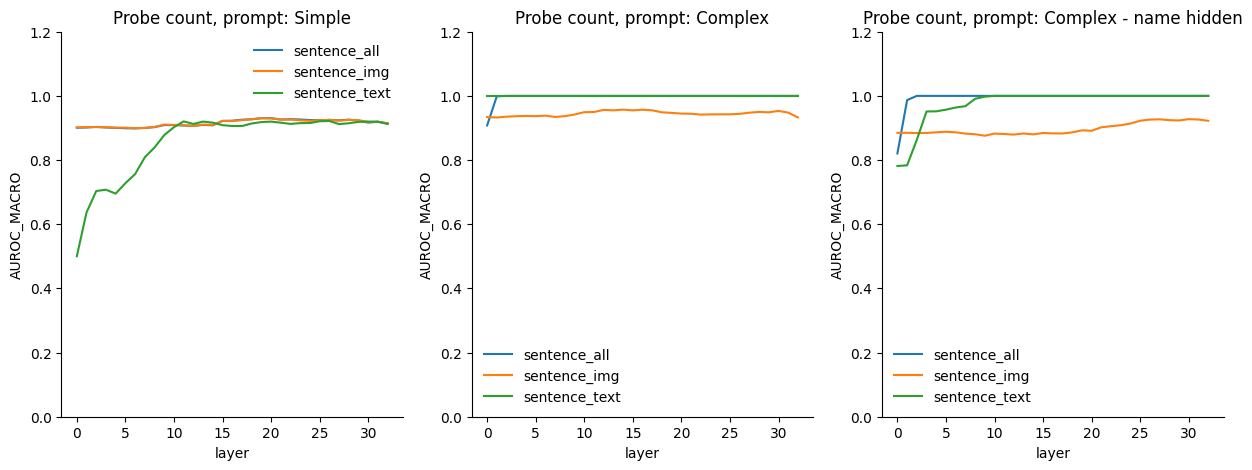

In [32]:

metric = 'auroc_macro'
prompt_level = ['Simple', 'Complex', 'Complex - name hidden']
fig, axs = plt.subplots(
    nrows=1,
    ncols=len(prompt_level),
    figsize=(5*len(prompt_level), 5)
)

for idx, prompt_type in enumerate(prompt_level):
    b = sns.lineplot(
        data=plot_df[plot_df['prompt_type']==prompt_type],
        x='layer',
        y=metric,
        hue='embedding_level',
        ax=axs[idx]
    )
    # b.axhline(auprc_baseline, color='black', linestyle='--')
    b.set(ylim=(0,1.2))
    b.legend(frameon=False)
    b.set_ylabel(metric.upper())
    b.set_title(f"Probe count, prompt: {prompt_type}")



sns.despine(top=True, right=True)